# HHOI DataLoader — Quick Test
Verify that the dataset loads correctly with annotation-based `_sp` train/test splits.

In [1]:
import sys, os
os.chdir(os.path.dirname(os.path.abspath('__file__')))
from dataloader import HHOIDataset, create_dataloader, load_annotation_splits
from pathlib import Path
print('Imports OK')

Imports OK


## 1. Annotation-based splits
Files ending with `_sp` → **train**, without → **test**.

In [2]:
ann_splits = load_annotation_splits(Path('annotations'))
for split, ids in ann_splits.items():
    print(f'{split:>5}: {len(ids)} sessions — {ids}')

train: 21 sessions — ['001080', '009106', '011034', '030082', '042084', '043079', '051076', '056109', '085190', '086087', '092096', '101139', '112132', '114166', '119145', '141183', '151165', '167168', '169171', '172185', '181182']
 test: 7 sessions — ['005013', '020025', '027113', '035040', '041083', '044156', '066067']


## 2. Load train & test datasets (text-only, no frames)

In [3]:
train_ds = HHOIDataset(split='train', load_frames=False)
test_ds  = HHOIDataset(split='test',  load_frames=False)

print(f'Train: {train_ds.num_sessions} sessions, {len(train_ds)} chunks — {train_ds.session_ids}')
print(f'Test:  {test_ds.num_sessions} sessions, {len(test_ds)} chunks — {test_ds.session_ids}')

Train: 13 sessions, 656 chunks — ['001080', '009106', '011034', '030082', '042084', '043079', '051076', '056109', '085190', '086087', '092096', '101139', '112132']
Test:  7 sessions, 411 chunks — ['005013', '020025', '027113', '035040', '041083', '044156', '066067']


## 3. Inspect a single sample

In [4]:
sample = train_ds[0]

print(f"Session:  {sample['session_id']}")
print(f"Chunk:    [{sample['chunk_start']:.1f}s — {sample['chunk_end']:.1f}s]")
print(f"Language: {sample['language']}")
print(f"Lego set: {sample['which_lego']}")
print(f"Words:    {len(sample['words'])}")
print(f"Segments: {len(sample['segments'])}")
print(f"Annotations: {len(sample['annotations'])}")
print()
print('--- Transcript (WhisperX) ---')
print(sample['transcript'][:500])
print()
print('--- Manual Transcript ---')
print(sample['manual_transcript'][:500])
print()
print('--- Annotations (first 5) ---')
for ann in sample['annotations'][:5]:
    subj = ann.get('subject', '?')
    act  = ann.get('act', '?')
    hl   = ann.get('high_level_action', 'none')
    ll   = ann.get('low_level_action', 'none')
    ut   = ann.get('utterance_type', 'none')
    label = ut if act == 'V' else f'{hl}/{ll}'
    print(f"  [{ann['start']:.1f}-{ann['end']:.1f}] {subj} ({act}): {label}")

Session:  001080
Chunk:    [0.0s — 10.0s]
Language: Spanish
Lego set: Locomotive
Words:    17
Segments: 3
Annotations: 14

--- Transcript (WhisperX) ---
[PART.1] Venga, más, vamos a por la primera.
[PART.1] Sí, la primera, ¿vale?
[PART.1] Venga, vamos a coger la azul, esa, muy bien.

--- Manual Transcript ---
PART.1: Venga, Marc,
vamos con la primera.
PART.2: Sí, son los primeros.
PART.1: Sí, la primera, ¿vale?
PART.2: A ver.
PART.1: Venga.
PART.2: Entonces, eh...
La azul.
PART.1: La azul.
Esa, muy bien.

--- Annotations (first 5) ---
  [0.2-0.6] participant_a (V): encourage
  [0.6-1.0] participant_a (NV): pay_attention/none
  [1.0-1.1] participant_b (NV): open/flip
  [2.7-2.7] participant_b (V): doubt
  [3.0-3.1] participant_b (NV): inspect_check/flip


## 4. Test batched DataLoader

In [5]:
loader = create_dataloader(
    split='train',
    batch_size=4,
    load_frames=False,
)

batch = next(iter(loader))
print(f"Batch keys:     {list(batch.keys())}")
print(f"Sessions:       {batch['session_id']}")
print(f"Chunks:         {list(zip(batch['chunk_start'], batch['chunk_end']))}")
print(f"Words per item: {[len(w) for w in batch['words']]}")
print(f"Annots/item:    {[len(a) for a in batch['annotations']]}")
print(f"\nTotal batches:  {len(loader)}")

Batch keys:     ['transcript', 'manual_transcript', 'part1_id', 'segments', 'split', 'which_lego', 'metadata', 'video_path', 'language', 'chunk_start', 'chunk_end', 'annotations', 'words', 'chunk_index', 'session_id', 'part2_id', 'frames']
Sessions:       ['042084', '030082', '056109', '042084']
Chunks:         [(265.0, 275.0), (435.0, 445.0), (150.0, 160.0), (310.0, 320.0)]
Words per item: [7, 9, 21, 12]
Annots/item:    [20, 27, 20, 20]

Total batches:  164


## 5. Test with video frames + chunk video bytes (small batch)

In [ ]:
frame_ds = HHOIDataset(
    split='train',
    fps=2,
    resize=(224, 224),
    crop_right=True,
    load_frames=True,
    load_video=True,
 )

sample = frame_ds[0]
print(f"Frames shape: {sample['frames'].shape}  (T, C, H, W)")
print(f"Frames dtype: {sample['frames'].dtype}")
print(f"Value range:  [{sample['frames'].min():.2f}, {sample['frames'].max():.2f}]")
print(f"Video bytes:  {len(sample['video']) if sample['video'] is not None else 0}")
print(f"Video mime:   {sample['video_mime']}")

Frames shape: torch.Size([20, 3, 224, 224])  (T, C, H, W)
Frames dtype: torch.float32
Value range:  [0.00, 1.00]


## 6. Per-session annotation stats

In [7]:
for split_name, ds in [('train', train_ds), ('test', test_ds)]:
    print(f'\n=== {split_name.upper()} ===')
    for sid in ds.session_ids:
        info = ds.get_session_info(sid)
        print(f"  {sid}: duration={info['duration']:.0f}s, "
              f"segments={info['num_segments']}, "
              f"annotations={info['num_annotations']}")


=== TRAIN ===
  001080: duration=245s, segments=119, annotations=628
  009106: duration=152s, segments=32, annotations=433
  011034: duration=312s, segments=110, annotations=859
  030082: duration=701s, segments=280, annotations=1955
  042084: duration=363s, segments=132, annotations=858
  043079: duration=105s, segments=35, annotations=281
  051076: duration=91s, segments=24, annotations=253
  056109: duration=197s, segments=70, annotations=503
  085190: duration=260s, segments=139, annotations=514
  086087: duration=107s, segments=39, annotations=324
  092096: duration=135s, segments=36, annotations=338
  101139: duration=374s, segments=115, annotations=1009
  112132: duration=216s, segments=77, annotations=642

=== TEST ===
  005013: duration=374s, segments=86, annotations=594
  020025: duration=161s, segments=53, annotations=283
  027113: duration=308s, segments=65, annotations=570
  035040: duration=141s, segments=60, annotations=227
  041083: duration=564s, segments=220, annotat

## 7. Inspect a sample with images
Display a few frames from one sample and inspect its metadata.

Session: 001080
Chunk:   [0.0s — 10.0s]
Frames:  (20, 3, 224, 224)


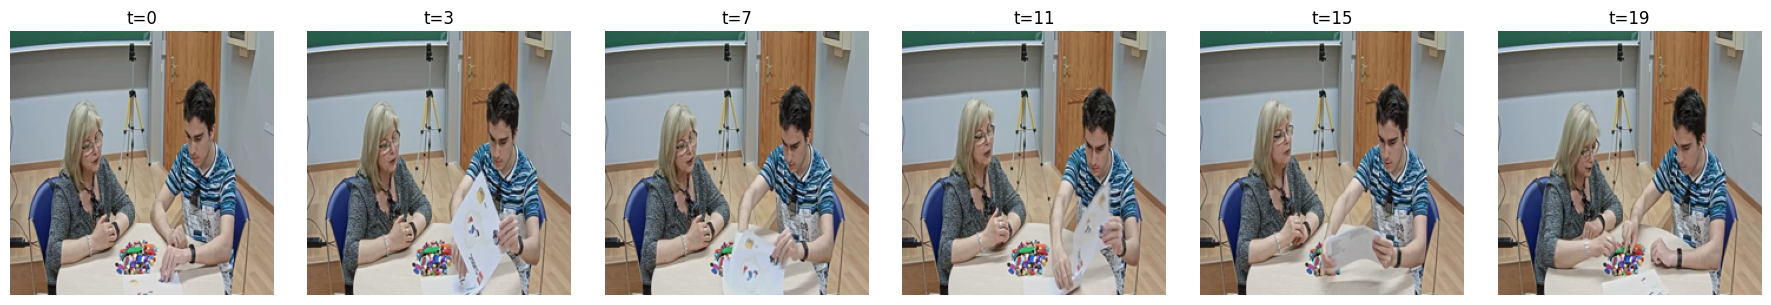

In [9]:
import matplotlib.pyplot as plt
import numpy as np

img_sample = frame_ds[0]
frames = img_sample['frames']  # (T, C, H, W)
print(f"Session: {img_sample['session_id']}")
print(f"Chunk:   [{img_sample['chunk_start']:.1f}s — {img_sample['chunk_end']:.1f}s]")
print(f"Frames:  {tuple(frames.shape)}")

# pick up to 6 evenly-spaced frames
num_show = min(6, frames.shape[0])
indices = np.linspace(0, frames.shape[0] - 1, num_show, dtype=int)

fig, axes = plt.subplots(1, num_show, figsize=(3 * num_show, 3))
if num_show == 1:
    axes = [axes]

for ax, idx in zip(axes, indices):
    img = frames[idx].permute(1, 2, 0).cpu().numpy()  # H, W, C
    # if normalized to [0, 1] or [-1, 1], clip safely for display
    if img.min() < 0:
        img = (img + 1) / 2
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.set_title(f"t={idx}")
    ax.axis('off')

plt.tight_layout()
plt.show()

## 8. Full sample inspection (ALL modalities)
Dump all sample fields (metadata, text, segments, annotations, frames) in one place.

=== FULL SAMPLE @ index 0 ===
Top-level keys (17): ['annotations', 'chunk_end', 'chunk_index', 'chunk_start', 'frames', 'language', 'manual_transcript', 'metadata', 'part1_id', 'part2_id', 'segments', 'session_id', 'split', 'transcript', 'video_path', 'which_lego', 'words']

=== SCALARS / METADATA ===
session_id: 001080
chunk_start: 0.0
chunk_end: 10.0
language: Spanish
which_lego: Locomotive

=== TEXT FIELDS (FULL) ===

--- transcript (chars=130) ---
[PART.1] Venga, más, vamos a por la primera.
[PART.1] Sí, la primera, ¿vale?
[PART.1] Venga, vamos a coger la azul, esa, muy bien.

--- manual_transcript (chars=198) ---
PART.1: Venga, Marc,
vamos con la primera.
PART.2: Sí, son los primeros.
PART.1: Sí, la primera, ¿vale?
PART.2: A ver.
PART.1: Venga.
PART.2: Entonces, eh...
La azul.
PART.1: La azul.
Esa, muy bien.

=== WORDS ===
num_words: 17
[{'end': 0.471,
  'score': 0.877,
  'speaker': 'PART.1',
  'start': 0.211,
  'word': 'Venga,'},
 {'end': 0.691,
  'score': 0.844,
  'speaker': 'PA

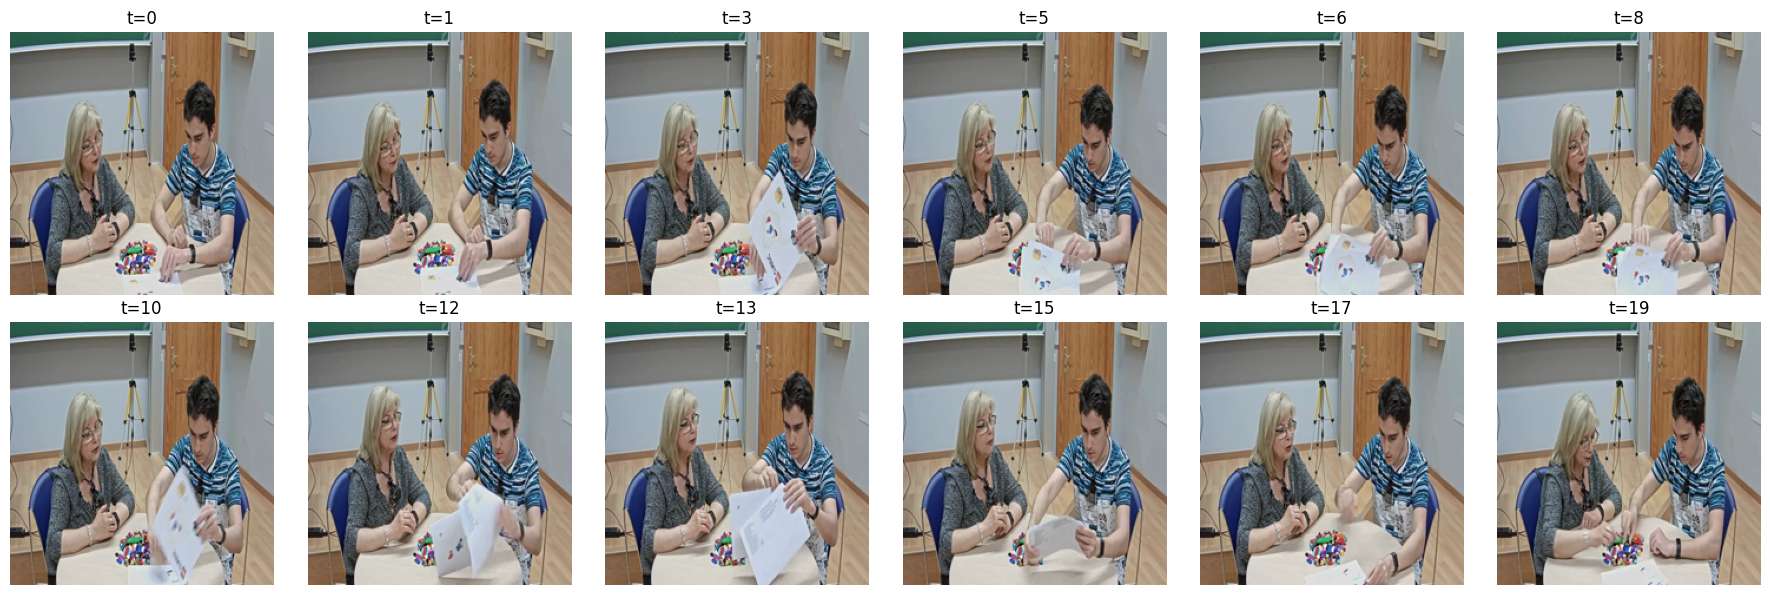

In [ ]:
from pprint import pprint
import numpy as np
import matplotlib.pyplot as plt

sample_idx = 0
display_all_frames = False   # set True to plot every frame
max_frames_preview = 12      # used when display_all_frames=False

full = frame_ds[sample_idx]
print(f"=== FULL SAMPLE @ index {sample_idx} ===")
print(f"Top-level keys ({len(full)}): {sorted(full.keys())}")

print("\n=== SCALARS / METADATA ===")
for key in ['session_id', 'chunk_start', 'chunk_end', 'language', 'which_lego']:
    if key in full:
        print(f"{key}: {full[key]}")

print("\n=== TEXT FIELDS (FULL) ===")
for key in ['transcript', 'manual_transcript']:
    if key in full:
        text = full[key]
        print(f"\n--- {key} (chars={len(text)}) ---")
        print(text)

print("\n=== WORDS ===")
if 'words' in full:
    print(f"num_words: {len(full['words'])}")
    pprint(full['words'])

print("\n=== SEGMENTS ===")
if 'segments' in full:
    print(f"num_segments: {len(full['segments'])}")
    pprint(full['segments'])

print("\n=== ANNOTATIONS ===")
if 'annotations' in full:
    print(f"num_annotations: {len(full['annotations'])}")
    pprint(full['annotations'])

print("\n=== VIDEO BYTES ===")
video_bytes = full.get('video', None)
if video_bytes is None:
    print('No chunk video bytes (load_video may be False).')
else:
    print(f"video bytes: {len(video_bytes)}")
    print(f"video mime:  {full.get('video_mime')}")

print("\n=== FRAMES TENSOR ===")
frames = full.get('frames', None)
if frames is None:
    print('No frames in this sample (load_frames may be False).')
else:
    print(f"shape: {tuple(frames.shape)}  (T, C, H, W)")
    print(f"dtype: {frames.dtype}")
    print(f"value range: [{frames.min().item():.4f}, {frames.max().item():.4f}]")

    t = frames.shape[0]
    if display_all_frames:
        idxs = np.arange(t)
    else:
        n = min(max_frames_preview, t)
        idxs = np.linspace(0, t - 1, n, dtype=int)

    cols = min(6, len(idxs))
    rows = int(np.ceil(len(idxs) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
    axes = np.array(axes).reshape(-1)

    for ax in axes[len(idxs):]:
        ax.axis('off')

    for ax, idx in zip(axes, idxs):
        img = frames[idx].permute(1, 2, 0).cpu().numpy()
        if img.min() < 0:
            img = (img + 1) / 2
        img = np.clip(img, 0, 1)
        ax.imshow(img)
        ax.set_title(f"t={idx}")
        ax.axis('off')

    plt.tight_layout()
    plt.show()

## 9. Save and preview chunk video
Write the chunk MP4 bytes to disk and render it inline (if available).

In [ ]:
from pathlib import Path
from IPython.display import Video, display

video_sample = frame_ds[0]
video_bytes = video_sample.get('video', None)

if video_bytes is None or len(video_bytes) == 0:
    print('No video bytes available. Recreate dataset with load_video=True.')
else:
    out_dir = Path('tmp_chunks')
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / f"{video_sample['session_id']}_chunk_{video_sample['chunk_index']:04d}.mp4"
    out_path.write_bytes(video_bytes)

    print(f"Saved chunk video: {out_path} ({len(video_bytes)} bytes)")
    print(f"Chunk window: [{video_sample['chunk_start']:.1f}s - {video_sample['chunk_end']:.1f}s]")
    display(Video(filename=str(out_path), embed=True))